<a href="https://colab.research.google.com/github/Vladislav-spect/DeepLearningSchool/blob/main/logistic_regression_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Семинар. Логистическая регрессия</b></h1>

В этом семинаре мы создадим свой класс логистической регрессии, который обучим с помощью градиентного спуска.

Логистическая регрессия --- это линейный алгоритм классификации на два класса $\{0, 1\}$, основанный на подборе весов модели для оптимизации логистической функции потерь.

**Предсказания.** С помощью функции сигмоиды:
$$\sigma(t) = \frac{1}{1 + e^{-t}}$$ можно вычислять вероятность принадлежности объекта классу $+1$ против класса $0$ по формуле $$y_{pred} = \sigma(\langle \mathbf{x}, \mathbf{w} \rangle).$$

Значение $\langle \mathbf{x}, \mathbf{w} \rangle$, то есть выход модели до применения сигмоиды, часто называют **логитом**.


**Функция потерь.**  В качестве функции потерь выступает LogLoss (логистическая функция потерь). Для одного объекта:

$$
L(\mathbf{w}) = -y\, \log\,y_{pred} - (1-y)\,\log\,(1-y_{pred})
$$

Здесь

* $\mathbf{x} = (1, x_1, \ldots, x_n)$ --- вектор признаков объекта (нулевой признак отвечает за свободный член в скалярном произведении $\langle \mathbf{x}, \mathbf{w}\rangle$);
* $y \in \{0, 1\}$ --- метка (истинного) класса объекта;
* $y_{pred} = \sigma(\langle \mathbf{x}, \mathbf{w} \rangle)$ -- вероятность класса $1$, предсказанная моделью;
* $\mathbf{w} = (w_0, w_1, \ldots, w_n)$ --- вектор весов ($w_0$ играет роль свободного члена).


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4611/203991869.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(grid, 1. / (1 + np.exp(-grid)), label='$\sigma(x)$')


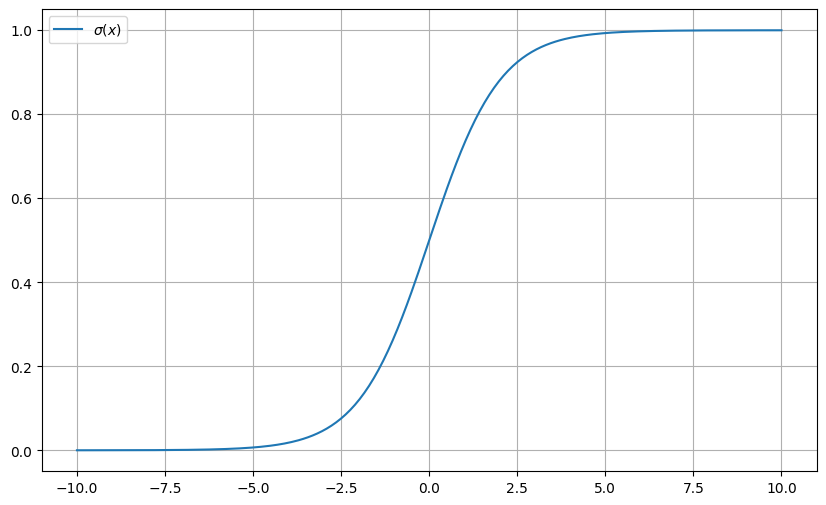

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


grid = np.linspace(-10, 10, 300)

plt.figure(figsize=(10,6))
plt.plot(grid, 1. / (1 + np.exp(-grid)), label='$\sigma(x)$')
plt.legend()
plt.grid(True)
plt.show()

Процесс подбора логистической регрессии состоит в градиентном спуске производится (стохастическим) градиентным спуском.

**Градиент функции потерь для одного объекта**:
$$
\frac{\partial{L}}{\partial{\mathbf{w}}}
= \left(-\frac{y}{y_{pred}} + \frac{1-y}{1-y_{pred}}\right)\frac{\partial{y_{pred}}}{\partial{\mathbf{w}}}
$$

$$
\frac{\partial{y_{pred}}}{\partial{\mathbf{w}}} = \frac{-1}{(1+e^{-\langle \mathbf{x}, \mathbf{w} \rangle})^2} e^{-\langle \mathbf{x}, \mathbf{w} \rangle} (-\mathbf{x}) = y_{pred}(1-y_{pred})\mathbf{x}
$$

$$
\frac{\partial{L}}{\partial{\mathbf{w}}} = (y_{pred} - y) \mathbf{x}
$$

**Шаг градиентного спуска для всей матрицы $X$**:

$$
\frac{\partial{L}}{\partial{\mathbf{w}}} = \frac{1}{\ell}((\mathbf{y}_{pred} - \mathbf{y})^TX)^T = \frac{1}{\ell}X^T(\mathbf{y}_{pred} - \mathbf{y}).
$$


**Шаг градиентного спуска**:
$$\mathbf{w} := \mathbf{w} - \alpha \frac{\partial{L}}{\partial{\mathbf{w}}}.$$



## Свой класс логистической регрессии
Реализуйте методы класса логистической регрессии. Произведите обучение градиентным спуском по всей выборке с фиксированным градиентным спуском.

In [ ]:
class MyLogisticRegression(object):
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None


    def sigmoid(self, t):
        return 1. / (1 + np.exp(-t))


    def grad(self, X, y_true, y_pred):
        l = X.shape[0]
        grad = X.T @ (y_pred - y_true) / l

        return grad


    def fit(self, X, y, max_iter=100, lr=0.1):
        # Принимает на вход X, y и вычисляет веса по данной выборке.
        # Множество допустимых классов: {0, 1}
        # Не забудьте про фиктивный признак, равный 1!
        X = np.array(X)
        y = np.array(y)
        assert len(y.shape) == 1 and len(X.shape) == 2
        assert X.shape[0] == y.shape[0]

        y = y[:, np.newaxis]
        l, n = X.shape
        # Добавляем признак из единиц
        X = np.hstack([np.ones([X.shape[0], 1]), X])  # [l, n+1]

        # Инициализируем веса
        weights = np.random.randn(n+1, 1)

        losses = []

        for iter_num in range(max_iter):
            # calculate grad
            logits = X @ weights  # [l, 1]
            y_pred = self.sigmoid(logits)  # [l, 1]
            grad = self.grad(X, y, y_pred)  # [n+1, 1]
            # update weights
            weights -= grad * lr

            # calculate loss
            loss = self.loss(y, y_pred)
            losses.append(loss)

        # assign coef, intersept
        self.coef_ = weights[1:]
        self.intercept_ = weights[0]

        return losses


    def predict_proba(self, X):
        # Принимает на вход X и возвращает ответы модели
        X = np.array(X)
        X = np.hstack([np.ones([X.shape[0], 1]), X])  # слева добавляем столбец единиц
        weights = np.concatenate([self.intercept_.reshape(-1, 1), self.coef_], axis=0) #reshape(-1, 1) — это способ превратить одномерный массив (или скаляр) в двумерный массив-столбец.
#-1 означает, что NumPy сам определит размер по количеству элементов,
#1 задаёт количество столбцов.
#В данном случае self.intercept_ — это скаляр (число). После reshape(-1, 1) он становится массивом формы (1, 1)
# Далее мы объединяем коэффициент при свободном члене(intercept_) и наши коэффициенты при признаке по вертикальному вектору
        logits = (X @ weights)  # [l, 1]

        return self.sigmoid(logits)


    def predict(self, X, threshold=0.5):
        return self.predict_proba(X) >= threshold


    def loss(self, y, p):
        p = np.clip(p, 1e-10, 1 - 1e-10) #np.clip(p, 1e-10, 1 - 1e-10) обрезает значения вероятностей p так,
        #чтобы они не выходили за пределы [1e-10, 1-1e-10]. Это необходимо, чтобы избежать логарифмирования
        #нуля (или единицы), так как log(0) не определён (стремится к -∞), а log(1) = 0, но при p=1 возникает
        #log(0) во втором слагаемом. Ограничение очень малым числом и близким к 1 (но не равным) обеспечивает численную стабильность.
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        '''y и p — это массивы, и операции y * np.log(p) и (1 - y) * np.log(1 - p)
        выполняются поэлементно над всеми объектами сразу, возвращая массивы такой же длины. Затем np.mean
        усредняет эти значения по всем объектам, давая скаляр — среднюю потерю на всей выборке.
        Это и есть эмпирический риск. Векторизация позволяет обойтись без цикла, что эффективнее.'''

## Создание датасета

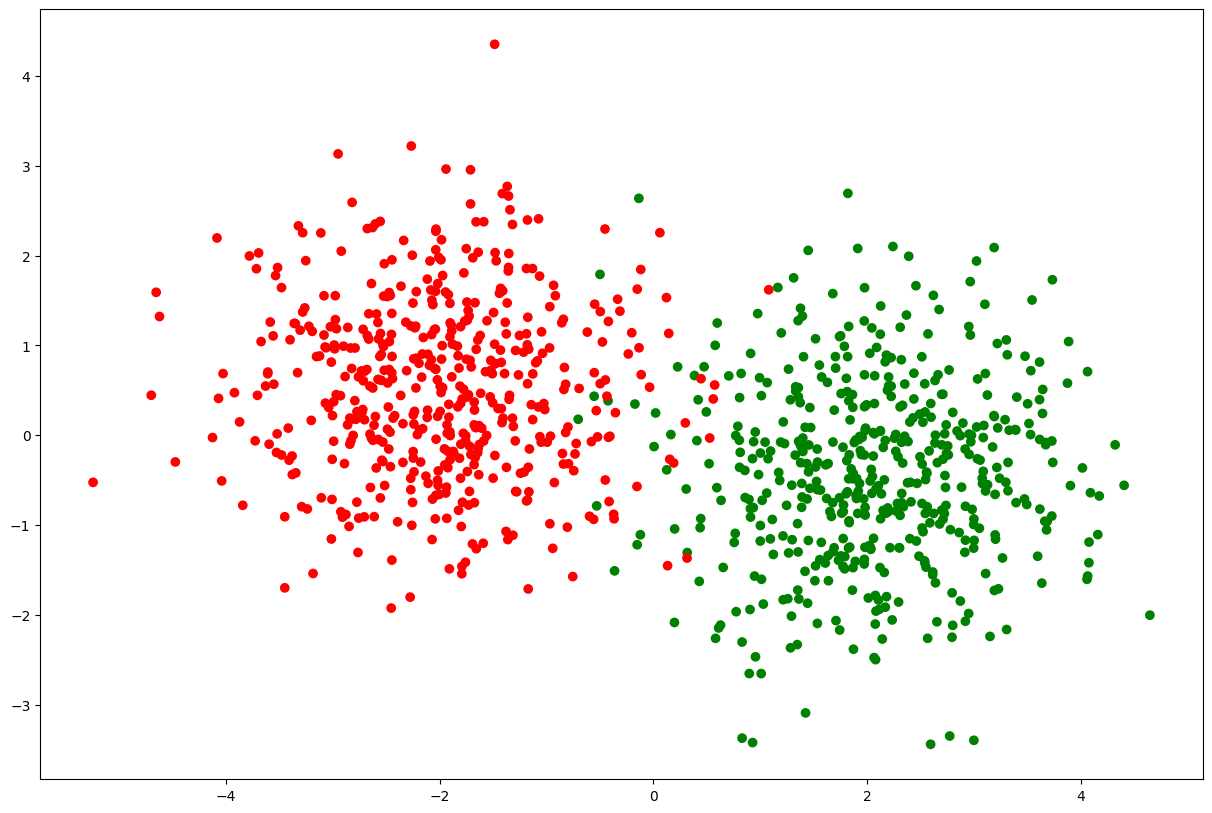

In [ ]:
from sklearn.datasets import make_blobs
#y — это массив, который возвращает функция make_blobs. Он содержит метки классов для каждой точки.
#Например, если у вас 1000 точек и 2 центра, то y будет массивом из 1000 чисел, каждое из которых — либо 0,
# либо 1. Это уже готовые метки.


X, y = make_blobs(n_samples=1000, centers=[[-2,0.5],[2,-0.5]], cluster_std=1, random_state=42)
#cluster_std=1 — стандартное отклонение точек от центра (чем больше, тем сильнее разброс).

colors = ("red", "green")
colored_y = np.zeros(y.size, dtype=str) #создаётся массив строк длиной, равной количеству точек (1000). Изначально все элементы — пустые строки ''
for i, cl in enumerate([0,1]):
    colored_y[y == cl] = str(colors[i])
#y == cl — это сравнение каждого элемента массива y с числом cl. Результат — булевый массив (из True и False)
#такой же длины, как y. True стоит на тех позициях, где значение в y равно cl.
#На примере с y = [0, 1, 0, 1, 0]:
#y == 0 даст [True, False, True, False, True]
#y == 1 даст [False, True, False, True, False]

#colored_y — это массив строк, изначально заполненный пустыми строками ''. Когда мы пишем colored_y[y == cl],
 #мы выбираем те элементы colored_y, которые находятся на позициях с True в булевом массиве.
 #И затем присваиваем им новое значение.

plt.figure(figsize=(15,10))
plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.show()

In [ ]:
clf = MyLogisticRegression()

losses = clf.fit(X, y, max_iter=1000)

coef, intercept = clf.coef_, clf.intercept_

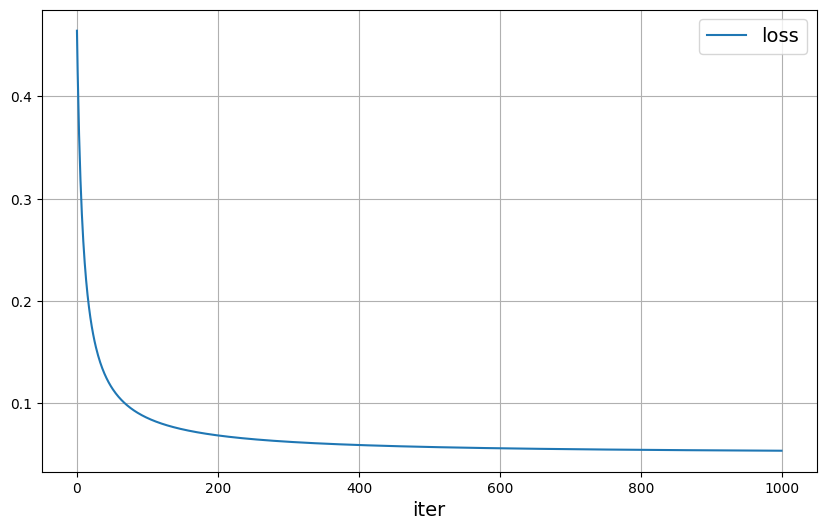

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(losses, label='loss')
plt.legend(fontsize=14)
plt.xlabel('iter', fontsize=14)
plt.grid()

In [ ]:
coef, intercept

#Вы правы, что в классической логистической регрессии число коэффициентов соответствует числу признаков.
#В вашем случае X имеет два признака, поскольку make_blobs по умолчанию генерирует двумерные данные
#(n_features=2). Поэтому и получилось два коэффициента:
#coef_[0] — коэффициент для первого признака,
#coef_[1] — коэффициент для второго признака.

(array([[ 3.06143743],
        [-0.63834281]]),
 array([-0.09437275]))

## Визуализация результатов

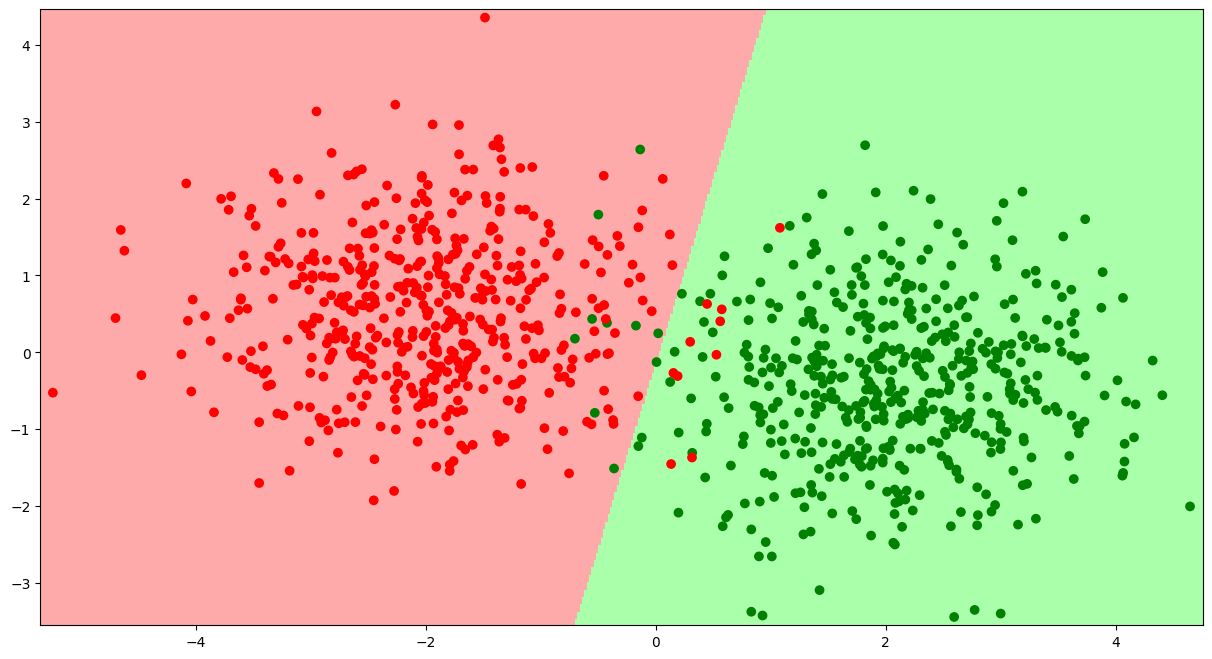

In [ ]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

plt.figure(figsize=(15,8))

eps = 0.1 #Мы не хотим предсказывать только для наших точек. Мы хотим нарисовать цветной фон, который покажет,
#как наша модель относит любую точку на плоскости к одному из двух классов.
#Для этого мы покрываем всю область, где есть данные (и чуть шире), частой сеткой из 500×500 = 250 000 точек.
# Для каждой из них получаем предсказание модели. Затем закрашиваем ячейки между этими точками в
#соответствующий цвет. Так получается плавная цветная карта, по которой видно, где граница между классами.
xx, yy = np.meshgrid(np.linspace(np.min(X[:,0]) - eps, np.max(X[:,0]) + eps, 500),
                     np.linspace(np.min(X[:,1]) - eps, np.max(X[:,1]) + eps, 500))


#xx — это матрица размером 500×500 (сетка координат по оси X).
#.ravel() превращает эту матрицу в один длинный массив из 250 000 чисел, просто вытягивая все строки в одну.
#Потому что модели predict нужно подавать список точек в формате (n_samples, n_features).
#У нас две координаты (признака), значит для каждой точки нужна пара (x, y).
#Мы вытягиваем xx и yy в одномерные массивы, а затем объединяем их попарно.
Z = clf.predict(np.stack([xx.ravel(), yy.ravel()]).T)

#После predict мы получаем одномерный массив Z из 250 000 предсказаний (0 или 1).
#Чтобы нарисовать цветную сетку с помощью pcolormesh, нужно, чтобы Z имел такую же форму, как xx и yy (500×500).
#.reshape(xx.shape) превращает одномерный массив обратно в матрицу 500×500, где элемент
#Z[i,j] соответствует предсказанию для точки (xx[i,j], yy[i,j]).
#Это нужно, чтобы pcolormesh знал, какой цвет рисовать в каждой ячейке.
Z = Z.reshape(xx.shape)
# Создаём цветовую карту для областей: светло-красный (#FFAAAA) для класса 0,
# светло-зелёный (#AAFFAA) для класса 1
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
# pcolormesh рисует залитые цветом ячейки сетки, показывая, какую область относит модель к каждому классу
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.show()

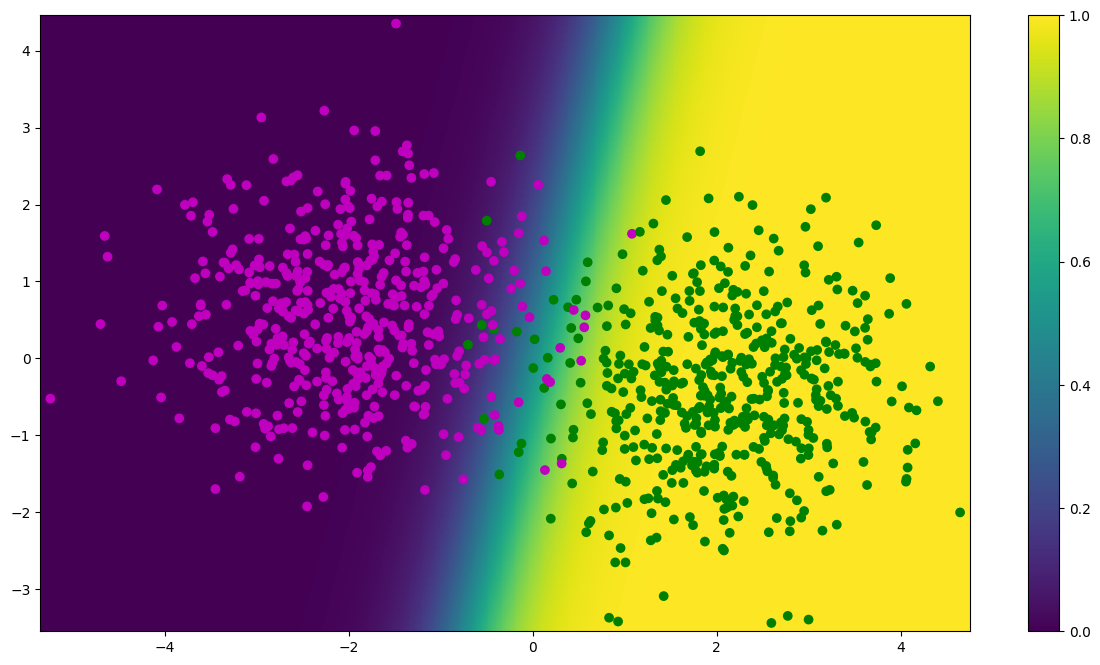

In [ ]:
colors = ("magenta", "green")
colored_y = np.zeros(y.size, dtype=str)

for i, cl in enumerate([0,1]):
    colored_y[y == cl] = str(colors[i])


plt.figure(figsize=(15,8))

Z = clf.predict_proba(np.stack([xx.ravel(), yy.ravel()]).T)

Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, cmap=plt.get_cmap('viridis'))

plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.colorbar()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y, clf.predict(X))

0.981